# 前向欧拉法求解大振幅单摆

- [周详](xiangzhou@whu.edu.cn)
- 武汉大学 
- 2026年9月13日

2026年9月13日

单摆的运动方程（$\theta$ 为摆线与竖直方向夹角）：

$$
\ddot{\theta} = -\frac{g}{L}\sin\theta
$$

化为一阶方程组：

$$
\frac{d\theta}{dt} = \omega, \qquad \frac{d\omega}{dt} = -\frac{g}{L}\sin\theta
$$

与简谐振子不同，方程右端含 $\sin\theta$，是**非线性**方程，不存在初等函数表示的封闭解。大振幅的本质效应是**周期随振幅增大而变长**，精确周期由第一类完全椭圆积分给出：

$$
T(\theta_0) = 4\sqrt{\frac{L}{g}}\;K\!\left(\sin^2\frac{\theta_0}{2}\right) \approx T_0\left(1 + \frac{\theta_0^2}{16} + \frac{11\theta_0^4}{3072} + \cdots\right), \qquad T_0 = 2\pi\sqrt{\frac{L}{g}}
$$

作为对照，小角近似 $\sin\theta \approx \theta$ 给出 $\theta_{\mathrm{sa}}(t) = \theta_0\cos(\omega_0 t)$，周期恒为 $T_0$。

**总机械能**（取最低点为势能零点）

$$
E = \tfrac{1}{2}mL^2\omega^2 + mgL(1 - \cos\theta)
$$

在真实运动中严格守恒。

**前向欧拉法（Forward Euler）** 的离散格式：

$$
\omega_{n+1} = \omega_n - h\frac{g}{L}\sin\theta_n, \qquad \theta_{n+1} = \theta_n + h\,\omega_n
$$

**运行之前，先把你的预测写下来**：

1. 周期：小角近似的 $T_0$ 在 $\theta_0 = 120°$ 时还准确吗？周期随振幅增大还是减小？
2. 能量：把欧拉更新代入 $E_{n+1}$，看看每步能量增量是否与状态无关；如果**依赖**状态（例如随 $\theta_n$ 变化），能量漂移会呈什么形状？
3. 本例步长 $h = 0.002$ s，远小于前两册（0.5 与 0.1 s）——为什么非线性摆需要小得多的步长？

带着预测运行下面的代码，逐条对照。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.integrate import solve_ivp
from scipy.special import ellipk

# 字体配置：按操作系统自动选择中文字体，
# 西文与数学公式用 Times New Roman 风格（STIX）
import platform
system = platform.system()
if system == 'Darwin':
    cn_font = 'Songti SC'
elif system == 'Windows':
    cn_font = 'SimSun'
else:  # Linux
    cn_font = 'Noto Serif CJK SC'

plt.rcParams['font.family'] = [cn_font, 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def forward_euler_pendulum(theta0, omega0, g, L, h, n_steps):
    """前向欧拉法求解单摆 dtheta/dt = omega, domega/dt = -(g/L) sin(theta)
    返回时间、角度、角速度数组（长度 n_steps + 1）"""
    t = np.arange(n_steps + 1) * h
    theta = np.empty(n_steps + 1)
    omega = np.empty(n_steps + 1)
    theta[0], omega[0] = theta0, omega0
    for n in range(n_steps):
        omega[n + 1] = omega[n] - h * (g / L) * np.sin(theta[n])
        theta[n + 1] = theta[n] + h * omega[n]
    return t, theta, omega


def reference_solution(theta0, omega0, g, L, t_end):
    """高精度参考解（RK45, rtol=1e-11），返回 dense_output 对象
    用 ref.sol(t) 获得任意时刻的 (theta, omega)"""
    sol = solve_ivp(
        lambda t, y: [y[1], -(g / L) * np.sin(y[0])],
        [0.0, t_end], [theta0, omega0],
        method='RK45', rtol=1e-11, atol=1e-12, dense_output=True
    )
    return sol

小角周期 T0 = 2.0071 s
θ0 = 120° 精确周期 T = 2.7555 s（T/T0 = 1.3729）
初始能量 E0 = 14.7000 J（守恒值）
末时刻能量漂移 = 1.3254 J（相对漂移 9.02%）
末时刻摆角误差 = -0.7127 rad


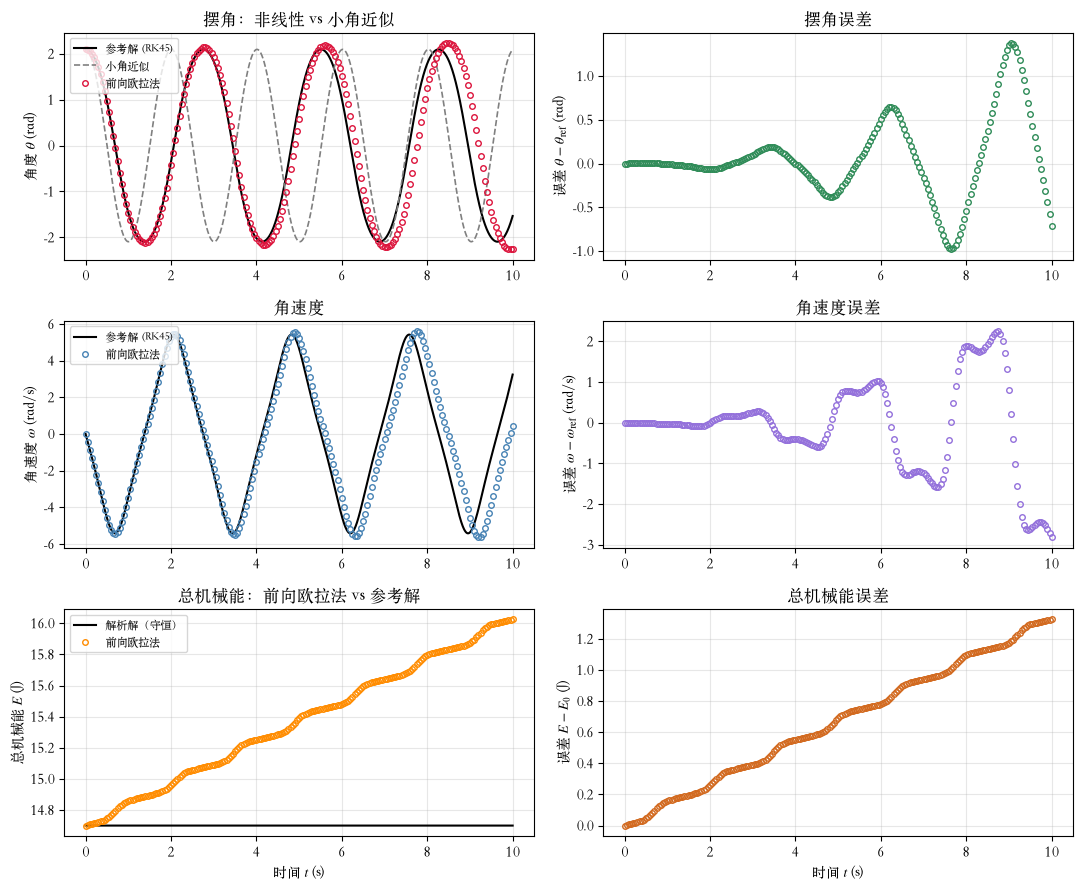

In [3]:
# 参数
theta0 = np.deg2rad(120.0)   # 初始摆角 (rad)，大振幅
omega0 = 0.0                 # 初始角速度 (rad/s)
m = 1.0                      # 摆球质量 (kg)
L = 1.0                      # 摆长 (m)
g = 9.8                      # 重力加速度 (m/s^2)
h = 0.002                    # 时间步长 (s)
t_end = 10.0                 # 总时间 (s)
om0 = np.sqrt(g / L)         # 小角频率
T0 = 2 * np.pi / om0         # 小角周期

t, theta, omg = forward_euler_pendulum(theta0, omega0, g, L, h, int(t_end / h))
ref = reference_solution(theta0, omega0, g, L, t_end)
theta_ref, omega_ref = ref.sol(t)
theta_sa = theta0 * np.cos(om0 * t)   # 小角近似

# 总机械能：E = 1/2 m L^2 omega^2 + m g L (1 - cos(theta))
E = 0.5 * m * L**2 * omg**2 + m * g * L * (1 - np.cos(theta))
E0 = 0.5 * m * L**2 * omega0**2 + m * g * L * (1 - np.cos(theta0))

err_theta = theta - theta_ref
err_omega = omg - omega_ref
err_E = E - E0

T_exact = 4 * np.sqrt(L / g) * ellipk(np.sin(theta0 / 2)**2)
print(f'小角周期 T0 = {T0:.4f} s')
print(f'θ0 = 120° 精确周期 T = {T_exact:.4f} s（T/T0 = {T_exact / T0:.4f}）')
print(f'初始能量 E0 = {E0:.4f} J（守恒值）')
print(f'末时刻能量漂移 = {E[-1] - E0:.4f} J（相对漂移 {100 * (E[-1] - E0) / E0:.2f}%）')
print(f'末时刻摆角误差 = {err_theta[-1]:.4f} rad')

fig, axs = plt.subplots(3, 2, figsize=(11, 9))

# 左列：数值解 vs 参考解
ax = axs[0, 0]
ax.plot(t, theta_ref, 'k-', lw=1.5, label='参考解 (RK45)')
ax.plot(t, theta_sa, '--', color='gray', lw=1.2, label='小角近似')
ax.plot(t, theta, 'o', ms=4, mfc='none', color='crimson', label='前向欧拉法', markevery=25)
ax.set_ylabel('角度 $\\theta$ (rad)')
ax.set_title('摆角：非线性 vs 小角近似')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

ax = axs[1, 0]
ax.plot(t, omega_ref, 'k-', lw=1.5, label='参考解 (RK45)')
ax.plot(t, omg, 'o', ms=4, mfc='none', color='steelblue', label='前向欧拉法', markevery=25)
ax.set_ylabel('角速度 $\\omega$ (rad/s)')
ax.set_title('角速度')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

ax = axs[2, 0]
ax.plot(t, np.full_like(t, E0), 'k-', lw=1.5, label='解析解（守恒）')
ax.plot(t, E, 'o', ms=4, mfc='none', color='darkorange', label='前向欧拉法', markevery=25)
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('总机械能 $E$ (J)')
ax.set_title('总机械能：前向欧拉法 vs 参考解')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# 右列：对应的误差（相对参考解，带符号）
ax = axs[0, 1]
ax.plot(t, err_theta, 'o', ms=4, mfc='none', color='seagreen', markevery=25)
ax.set_ylabel('误差 $\\theta - \\theta_{\\mathrm{ref}}$ (rad)')
ax.set_title('摆角误差')
ax.grid(alpha=0.3)

ax = axs[1, 1]
ax.plot(t, err_omega, 'o', ms=4, mfc='none', color='mediumpurple', markevery=25)
ax.set_ylabel('误差 $\\omega - \\omega_{\\mathrm{ref}}$ (rad/s)')
ax.set_title('角速度误差')
ax.grid(alpha=0.3)

ax = axs[2, 1]
ax.plot(t, err_E, 'o', ms=4, mfc='none', color='chocolate', markevery=25)
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('误差 $E - E_0$ (J)')
ax.set_title('总机械能误差')
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/4_simple_pendulum_euler_main.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

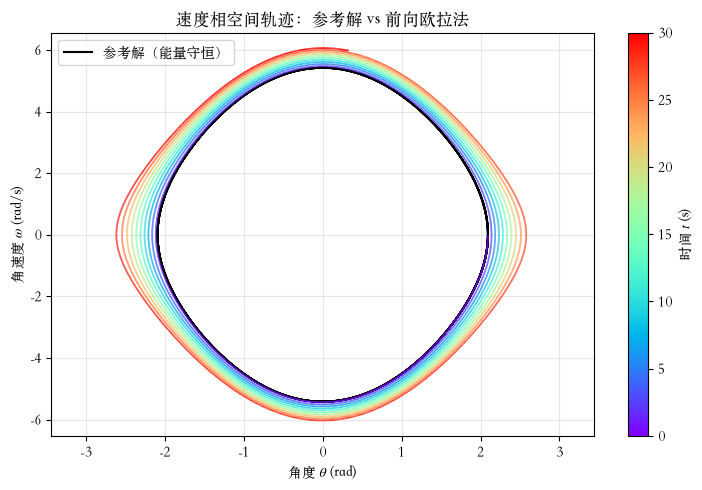

In [4]:
# 速度相空间轨迹：参考解 vs 前向欧拉法
# 用更长时间的欧拉解（30 s ≈ 11 个周期）
# 欧拉轨迹的线色随时间变化（见色条）：深色为起点，亮色为终点
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(theta_ref, omega_ref, 'k-', lw=1.5, label='参考解（能量守恒）')
t_s, theta_s, omg_s = forward_euler_pendulum(theta0, omega0, g, L, h, int(30.0 / h))

points = np.array([theta_s, omg_s]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='rainbow', array=t_s, lw=1.2)
ax.add_collection(lc)
cbar = fig.colorbar(lc, ax=ax)
cbar.set_label('时间 $t$ (s)')

ax.set_xlabel('角度 $\\theta$ (rad)')
ax.set_ylabel('角速度 $\\omega$ (rad/s)')
ax.set_xlim(-np.pi - 0.3, np.pi + 0.3)
ax.set_ylim(omg_s.min() - 0.5, omg_s.max() + 0.5)
ax.set_title('速度相空间轨迹：参考解 vs 前向欧拉法')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/4_simple_pendulum_euler_phase.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

## 速度相空间矢量场

单摆在速度相空间 $(\theta, \omega)$ 中的运动由矢量场

$$
\frac{d\theta}{dt} = \omega, \qquad \frac{d\omega}{dt} = -\frac{g}{L}\sin\theta
$$

决定：每一点处的箭头给出系统经过该状态时的运动方向。图中箭头已归一化为单位长度（只显示方向），颜色表示归一化速率。

几个要点：

- **中心点** $(0, 0)$：稳定平衡（摆到最低点），附近矢量场呈涡旋状，轨道绕其闭合。
- **鞍点** $(\pm\pi, 0)$：不稳定平衡（摆在最高点），附近矢量场呈双曲线状。
- **分界线（separatrix）** $E = 2mgL$：单摆恰好到达最高点的临界能量曲线，把速度相空间分为内部的**摆动区**（libration）与外部的**旋转区**（rotation，单摆绕轴转圈，$\theta$ 不再往复）。
- 矢量场处处与等能线相切，故真实解沿闭合轨道运动（能量守恒）；而前向欧拉解不断穿越等能线向外螺旋（见上图）。

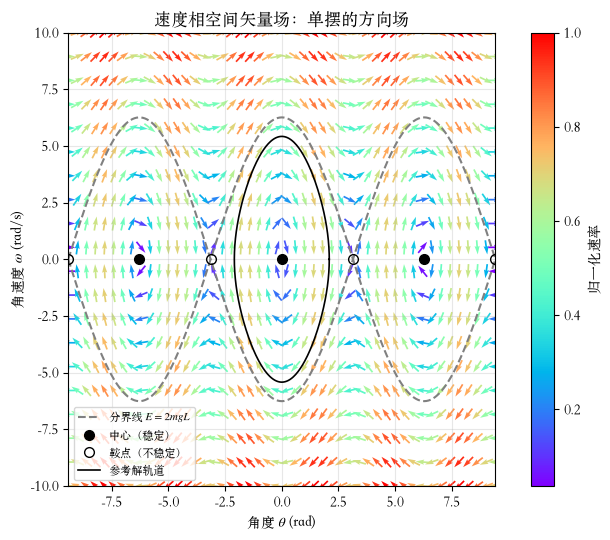

In [5]:
# 速度相空间矢量场：(dtheta/dt, domega/dt) = (omega, -(g/L) sin(theta))
# 箭头归一化为单位长度（只表示方向），颜色表示归一化速率
# 展示 ±3π 范围：轨道结构以 2π 为周期重复，每个周期胞内为中心 + 两侧鞍点
# 矢量场处处与等能线相切，故参考解轨道（黑色闭合曲线）能量守恒；
# 而前向欧拉解不断穿越等能线向外螺旋（见上图）
theta_grid = np.linspace(-3 * np.pi, 3 * np.pi, 48)
omega_grid = np.linspace(-10, 10, 20)
TH, OM = np.meshgrid(theta_grid, omega_grid)

U, V = OM, -(g / L) * np.sin(TH)
speed = np.sqrt(U**2 + V**2)
speed_norm = speed / speed.max()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
q = ax.quiver(TH, OM, U / speed, V / speed, speed_norm, cmap='rainbow',
              pivot='mid', scale=30, width=0.004)
cbar = fig.colorbar(q, ax=ax)
cbar.set_label('归一化速率')

# 分界线（separatrix）：E = 2mgL，区分摆动（libration）与旋转（rotation）
th_s = np.linspace(-3 * np.pi, 3 * np.pi, 601)
ax.plot(th_s, 2 * om0 * np.cos(th_s / 2), '--', color='gray', lw=1.5,
        label='分界线 $E = 2mgL$')
ax.plot(th_s, -2 * om0 * np.cos(th_s / 2), '--', color='gray', lw=1.5)

# 平衡点：中心 (0, ±2π) 稳定，鞍点 (±π, ±3π) 不稳定（以 2π 为周期重复）
ax.plot([0, 2 * np.pi, -2 * np.pi], [0, 0, 0], 'o', color='black', ms=7,
        zorder=5, label='中心（稳定）')
ax.plot([np.pi, -np.pi, 3 * np.pi, -3 * np.pi], [0, 0, 0, 0], 'o',
        mfc='none', color='black', ms=7, zorder=5, label='鞍点（不稳定）')

# 参考解轨道（初始条件同主算例）：矢量场处处与之相切
t_orb = np.linspace(0.0, T_exact, 400)
th_orb, om_orb = ref.sol(t_orb)
ax.plot(th_orb, om_orb, 'k-', lw=1.2, label='参考解轨道')

ax.set_xlabel('角度 $\\theta$ (rad)')
ax.set_ylabel('角速度 $\\omega$ (rad/s)')
ax.set_xlim(-3 * np.pi, 3 * np.pi)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')   # x、y 轴等比例：1 rad 与 1 rad/s 在图上长度相同
ax.set_title('速度相空间矢量场：单摆的方向场')
ax.legend(loc='lower left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig('outputs/4_simple_pendulum_euler_field.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

### 箭头的位置与颜色约定

- **位置**：每个箭头按 `pivot='mid'` 绘制——箭杆的**中点**恰落在它所描述的速度相空间格点 $(\theta_i,\,\omega_i)$ 上，并沿该点处的流方向对称延伸。读图时以箭杆中点为准。
- **颜色**：箭杆归一化为单位长度（只表示方向），矢量的**模长**改用颜色编码：按 $|(\dot\theta, \dot\omega)|\,/\,|(\dot\theta, \dot\omega)|_{\max}$ 以 rainbow 色条从蓝（慢）到红（快）着色。本例 $(\dot\theta, \dot\omega) = (\omega,\,-\tfrac{g}{L}\sin\theta)$，模长 $=\sqrt{\omega^2+(g\sin\theta/L)^2}$，故 $\theta=0$、$|\omega|$ 大处最快（红）；平衡点与转向点（$\omega=0,\ \theta\neq 0$，仅剩角加速度分量）最慢（蓝）。

方向（箭头指向）+ 模长（颜色）合在一起，完整给出矢量场的信息。

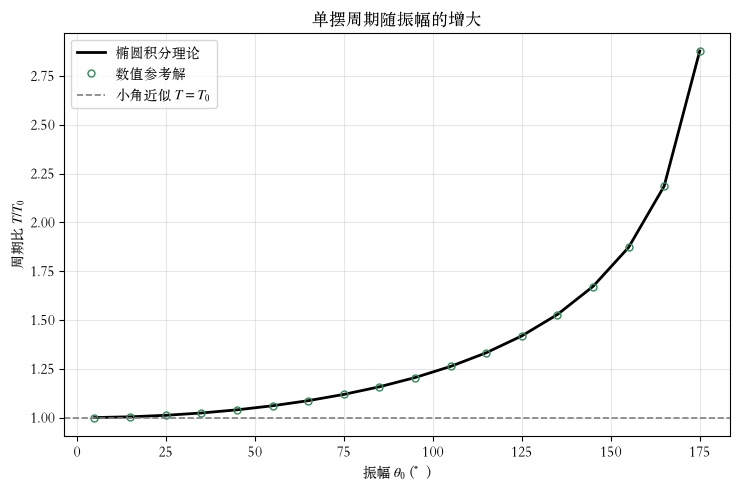

  振幅 (°)      T/T0 数值      T/T0 理论
       5       1.0005       1.0005
      15       1.0043       1.0043
      25       1.0120       1.0120
      35       1.0238       1.0238
      45       1.0400       1.0400
      55       1.0608       1.0608
      65       1.0869       1.0869
      75       1.1190       1.1190
      85       1.1579       1.1579
      95       1.2050       1.2050
     105       1.2622       1.2622
     115       1.3320       1.3320
     125       1.4185       1.4185
     135       1.5279       1.5279
     145       1.6715       1.6715
     155       1.8715       1.8715
     165       2.1854       2.1854
     175       2.8777       2.8777


In [6]:
# 周期随振幅的变化：数值周期 vs 椭圆积分理论
amp_deg = np.arange(5.0, 176.0, 10.0)   # 振幅（度）
amp = np.deg2rad(amp_deg)
t_max = 8.0 * T0                        # 积分时长，保证足够多过零点
t_dense = np.linspace(0.0, t_max, 200001)

T_ratio_num = []
T_ratio_exact = []
for a in amp:
    sol_a = reference_solution(a, 0.0, g, L, t_max)
    theta_a = sol_a.sol(t_dense)[0]
    # 检测 theta 的过零点（线性插值），相邻过零点间隔为半周期
    idx = np.where(np.diff(np.sign(theta_a)) != 0)[0]
    t_cross = t_dense[idx] + (t_dense[1] - t_dense[0]) * np.abs(theta_a[idx]) / (
        np.abs(theta_a[idx]) + np.abs(theta_a[idx + 1]))
    T_num = 2.0 * np.mean(np.diff(t_cross))
    T_ratio_num.append(T_num / T0)
    T_ratio_exact.append(4 * np.sqrt(L / g) * ellipk(np.sin(a / 2)**2) / T0)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(amp_deg, T_ratio_exact, 'k-', lw=2, label='椭圆积分理论')
ax.plot(amp_deg, T_ratio_num, 'o', ms=5, mfc='none', color='seagreen', label='数值参考解')
ax.axhline(1.0, color='gray', ls='--', lw=1.2, label='小角近似 $T = T_0$')
ax.set_xlabel('振幅 $\\theta_0$ (°)')
ax.set_ylabel('周期比 $T / T_0$')
ax.set_title('单摆周期随振幅的增大')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig('outputs/4_simple_pendulum_euler_period.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

print(f'{"振幅 (°)":>8} {"T/T0 数值":>12} {"T/T0 理论":>12}')
for d, r_n, r_e in zip(amp_deg, T_ratio_num, T_ratio_exact):
    print(f'{d:>8.0f} {r_n:>12.4f} {r_e:>12.4f}')

## 结论与思考

**先对照运行结果，回答引言中的三个预测**（周期与振幅的关系？能量是否守恒、漂移呈什么形状？为什么步长取得很小？）

**周期随振幅增大**：大振幅单摆最显著的物理效应。振幅 $120°$ 时周期约为主周期的 $1.37$ 倍（小角近似偏差 $37\%$），$90°$ 时约 $1.18$ 倍，即使 $10°$ 也约有 $0.2\%$ 的偏差。主图中可见小角近似余弦曲线与真实运动迅速错开相位，周期–振幅关系与椭圆积分理论完全吻合。

**能量漂移**：每步能量增量不再恒定，而是依赖状态——摆角越大注能越多，漂移只增不减；单位时间漂移 $\propto h$，减小步长只能线性减缓，长时间模拟仍会发散。

**与系列前例的对比**：匀速运动（欧拉精确）、自由落体（线性漂移）、简谐振子（每步恒定比例增长）、大振幅单摆（增量依赖状态、随振幅变化）。系统不同，漂移的"形状"不同，但教训相同：漂移是更新格式的**结构性缺陷**，减步长只能延缓、不能根除。